In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
N = 500

attendance_rate = np.clip(np.random.normal(80, 12, N), 30, 100)
tasks_assigned = np.random.randint(5, 15, N)
submission_rate = np.clip(np.random.normal(75, 15, N), 10, 100)
feedback_score = np.clip(np.random.normal(7.5, 1.5, N), 1, 10)
mentor_interactions = np.random.poisson(6, N)

score = (
    0.35 * (attendance_rate / 100) +
    0.30 * (submission_rate / 100) +
    0.20 * (feedback_score / 10) +
    0.15 * np.clip(mentor_interactions / 10, 0, 1)
)
score += np.random.normal(0, 0.08, N)
success = (score > np.median(score)).astype(int)

df = pd.DataFrame({
    'intern_id': [f'INT{i+1:04d}' for i in range(N)],
    'attendance_rate': attendance_rate.round(1),
    'tasks_assigned': tasks_assigned,
    'submission_rate': submission_rate.round(1),
    'feedback_score': feedback_score.round(1),
    'mentor_interactions': mentor_interactions,
    'success': success
})
df.to_csv('intern_performance_data.csv', index=False)
df.head()

,intern_id,attendance_rate,tasks_assigned,submission_rate,feedback_score,mentor_interactions,success
0,INT0001,86.0,14,59.4,8.4,3,1
1,INT0002,78.3,6,94.2,8.4,1,1
2,INT0003,87.8,12,71.1,6.7,2,0
3,INT0004,98.3,10,77.0,7.1,6,1
4,INT0005,77.2,9,81.2,5.7,8,1


In [3]:
X = df[['attendance_rate', 'submission_rate', 'feedback_score', 'mentor_interactions']]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 400, Test size: 100


In [4]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


Accuracy: 73.00%
              precision    recall  f1-score   support

           0       0.68      0.78      0.73        46
           1       0.79      0.69      0.73        54

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.74      0.73      0.73       100



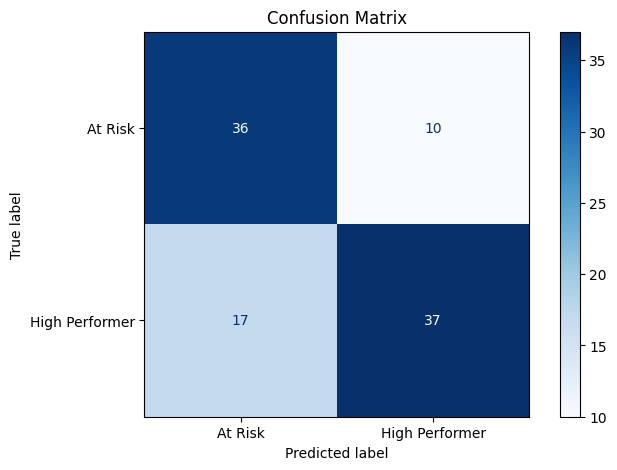

In [5]:
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc:.2%}")
print(classification_report(y_test, preds))

fig, ax = plt.subplots()
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=['At Risk', 'High Performer']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

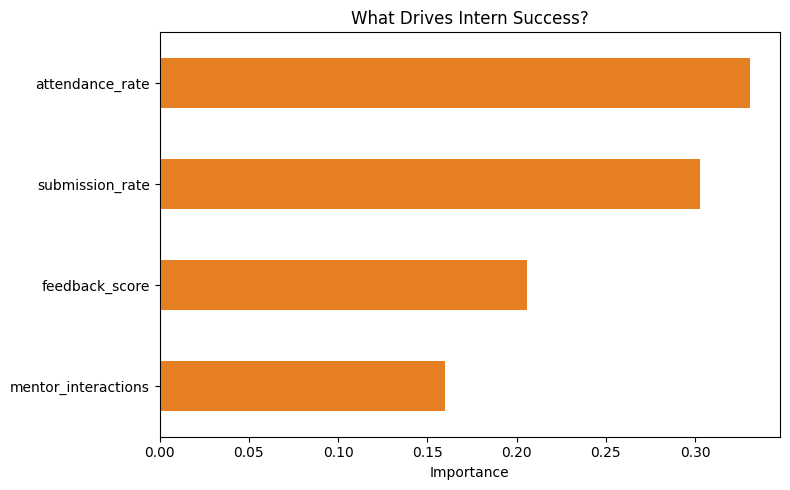

In [6]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
importances.plot(kind='barh', color='#e67e22', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('What Drives Intern Success?')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df['success_probability'] = model.predict_proba(X)[:, 1].round(3)
df['risk_flag'] = np.where(df['success_probability'] < 0.4, 'High Risk',
                    np.where(df['success_probability'] < 0.6, 'Watch List', 'On Track'))

df_sorted = df.sort_values('success_probability')
df_sorted.to_csv('intern_performance_predictions.csv', index=False)
df_sorted[['intern_id', 'attendance_rate', 'submission_rate', 'feedback_score',
           'success_probability', 'risk_flag']].head(10)

,intern_id,attendance_rate,submission_rate,feedback_score,success_probability,risk_flag
240,INT0241,70.5,51.6,4.7,0.005,High Risk
426,INT0427,68.4,51.9,4.9,0.005,High Risk
139,INT0140,65.2,57.8,8.9,0.010,High Risk
181,INT0182,69.7,67.6,5.8,0.010,High Risk
170,INT0171,69.3,63.9,7.1,0.010,High Risk
309,INT0310,77.6,65.2,5.9,0.015,High Risk
348,INT0349,71.4,51.7,9.0,0.015,High Risk
188,INT0189,69.8,71.1,6.3,0.015,High Risk
146,INT0147,65.2,64.3,8.8,0.020,High Risk
407,INT0408,78.3,70.5,5.8,0.020,High Risk


In [ ]:
# 73% accuracy predicting intern success
# Attendance + submission rate are the top two drivers (63% combined)
# risk_flag column flags interns needing proactive mentor outreach